In [ ]:
import pandas as pd

# load dztas
df = pd.read_csv("../data/games.csv")

In [2]:
# Aperçu
print(df.shape)
df.head()

(26651, 21)


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [8]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.3 MB 10.7 MB/s eta 0:00:01
   ------------------- -------------------- 4.5/9.3 MB 10.7 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 7.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df.info()

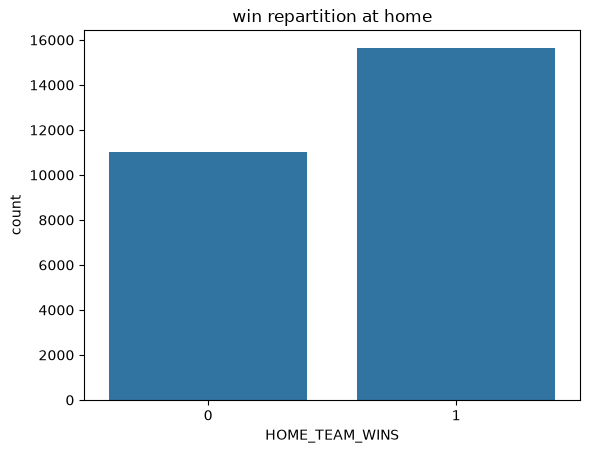

GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64


,PTS_home,PTS_away,FG_PCT_home,FG_PCT_away
count,26552.000000,26552.000000,26552.000000,26552.000000
mean,103.455898,100.639876,0.460735,0.449732
std,13.283370,13.435868,0.056676,0.055551
min,36.000000,33.000000,0.250000,0.244000
25%,94.000000,91.000000,0.422000,0.412000
50%,103.000000,100.000000,0.460000,0.449000
75%,112.000000,110.000000,0.500000,0.487000
max,168.000000,168.000000,0.684000,0.687000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Win loose at Home
sns.countplot(x="HOME_TEAM_WINS", data=df)
plt.title("win repartition at home")
plt.savefig("../outputs/figures/victory_repartition.png")
plt.show()

# missing values  

print(df.isnull().sum())

# stats 
df[["PTS_home", "PTS_away", "FG_PCT_home", "FG_PCT_away"]].describe()

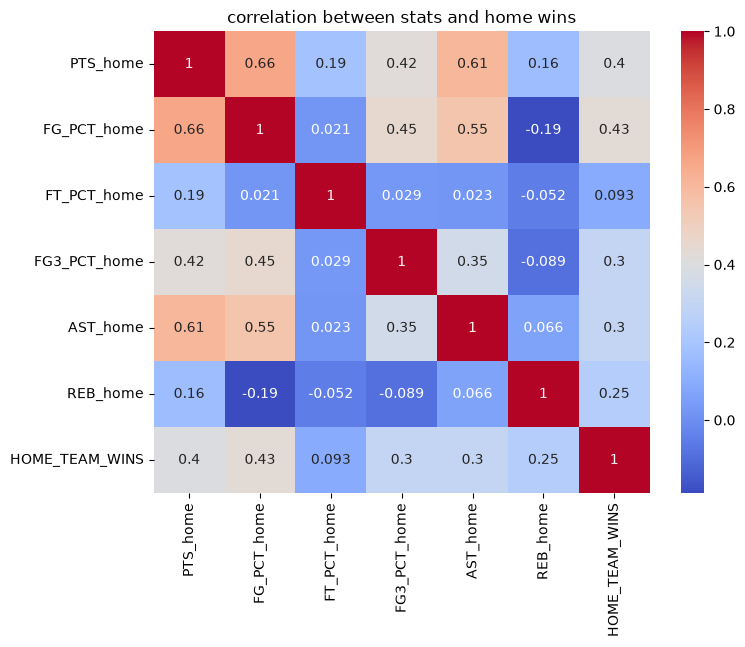

In [12]:
# correlation between stats and home wins
correlation = df[["PTS_home", "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home",
                   "AST_home", "REB_home", "HOME_TEAM_WINS"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("correlation between stats and home wins")
plt.savefig("../outputs/figures/correlation.png")
plt.show()

In [13]:
# useful columns
useful_columns = [
    "PTS_home", "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home", "AST_home", "REB_home",
    "PTS_away", "FG_PCT_away", "FT_PCT_away", "FG3_PCT_away", "AST_away", "REB_away",
    "HOME_TEAM_WINS"
]

df_clean = df[useful_columns].dropna()

print("before clean :", df.shape)
print("afterclean :", df_clean.shape)

before clean : (26651, 21)
afterclean : (26552, 13)


In [ ]:
# Séparation features (X) et cible (y)
X = df_clean.drop(columns=["HOME_TEAM_WINS"])
y = df_clean["HOME_TEAM_WINS"]

df_clean.to_csv("../data/games_clean.csv", index=False)